# **Введение**

Мы выбрали работу над гипотезой №2:

Нормализация по рядам особенно важна для глобальных нейронных

> Нормализация по рядам особенно важна для глобальных нейронных моделей, но влияет неоднозначно для моделей из разных классов.

Т.о. нам нужно дать ответы на два вопроса:

1. Как нормализация влияет на глобальные нейронные модели (сравнить до и после)

2. Как нормализация влияет на модели других классов (бустинги и т.п.)

Ноутбук разделен на следующие блоки:

- Загрузка и предобработка датасета (Electricity от https://forecastingdata.org/), разделение на тест и трейн, подготовка нормализованного и не нормализованного датасетов, выбор метрик

- Определение гаризонтов моделирования и выбор стратегии (Direct Mimo/Recursive etc), выбор метрик качества

- Написание функции для генерации expanding window (или rolling window)

- Построение бейзлайна на expanding window - Naive, NaiveSeasonal, AutoET

- Написание функций по генерации фичей и построение градиентных бустингов

- Построение глобальных нейронных моделей (LSTM) и сопоставление результатов на нормализованных и ненормализованных данных

- Оценка и интерпретация результата









**Результаты:**

Мы смогли убедиться в важности нормализации для нейросетевых моделей и огронмному разрыву в качестве для моделей с и без нормализации

Нормализация же данных для стат моделей и моделей машинного обучения (бустинг) не показала такого существенного прироста в качестве, однако минимальные улучшения можно наблюдать.

Сводная таблица по макро-усредненным метрикам представлена ниже:

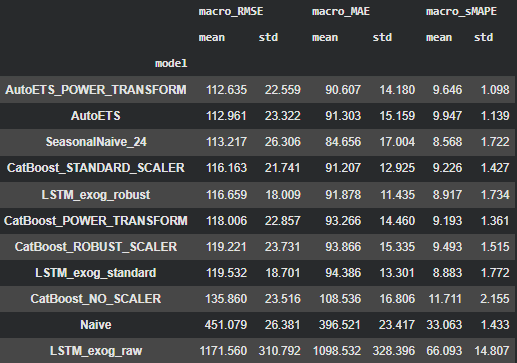

# **Часть 0. Загрузка, визуализиация и предобработка датасета**

В качестве датасета выбраны данные по потреблению энергии (аггрегированно по часу, 321 ряд):

https://zenodo.org/records/4656140



In [1]:
!pip install -q sktime

In [2]:
!pip install catboost

In [3]:
!pip install -U neuralforecast

In [4]:
!pip install statsforecast

In [5]:
!pip install mlforecast

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import torch
import torch.nn as nn
import torch.nn.functional as F
from plotly.subplots import make_subplots
from torch.utils.data import DataLoader, Dataset
import random

from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean, RollingStd, SeasonalRollingMean

In [7]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

In [8]:
from sktime.datasets import load_tsf_to_dataframe

path = "/content/electricity_hourly_dataset.tsf"

df, meta = load_tsf_to_dataframe(
    path,
    replace_missing_vals_with="NaN",
    value_column_name="series_value",
)

print(type(df))
print(meta)

/usr/local/lib/python3.12/dist-packages/sktime/datasets/_readers_writers/tsf.py:64: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  lambda x: pd.date_range(


<class 'pandas.core.frame.DataFrame'>
{'frequency': 'hourly', 'forecast_horizon': None, 'contain_missing_values': False, 'contain_equal_length': True}


/usr/local/lib/python3.12/dist-packages/sktime/datasets/_readers_writers/tsf.py:95: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.index.levels[-1].freq = freq


In [9]:
df.head(10)

series_value
series_name timestamp                        
T1          2012-01-01 00:00:01          14.0
            2012-01-01 01:00:01          18.0
            2012-01-01 02:00:01          21.0
            2012-01-01 03:00:01          20.0
            2012-01-01 04:00:01          22.0
            2012-01-01 05:00:01          20.0
            2012-01-01 06:00:01          20.0
            2012-01-01 07:00:01          20.0
            2012-01-01 08:00:01          13.0
            2012-01-01 09:00:01          11.0

In [10]:
min_max_dates = df.groupby(level='series_name').apply(lambda x: pd.Series({'min_date': x.index.get_level_values('timestamp').min(), 'max_date': x.index.get_level_values('timestamp').max()}))

display(min_max_dates.head())

,min_date,max_date
series_name,,
T1,2012-01-01 00:00:01,2014-12-31 23:00:01
T10,2012-01-01 00:00:01,2014-12-31 23:00:01
T100,2012-01-01 00:00:01,2014-12-31 23:00:01
T101,2012-01-01 00:00:01,2014-12-31 23:00:01
T102,2012-01-01 00:00:01,2014-12-31 23:00:01


In [11]:
#проверка есть ли разные значения начала и конца?
print(min_max_dates['min_date'].unique())
print(min_max_dates['max_date'].unique())

<DatetimeArray>
['2012-01-01 00:00:01']
Length: 1, dtype: datetime64[ns]
<DatetimeArray>
['2014-12-31 23:00:01']
Length: 1, dtype: datetime64[ns]


Т.к. датасет достаточно большой, для ускорения обучения возможно лучше будет оставить только часть timestamp и часть рядов

In [12]:
#обрежем по датам
print(df.shape)
START_DATE = '2013-12-01 00:00:01'
END_DATE = '2014-12-10 23:00:01'
NUM_SERIES = 20

df = df.sort_index()

# indices_to_keep = df.index.get_level_values('timestamp').isin(pd.date_range(START_DATE, END_DATE))
# data = df[indices_to_keep]

data = df.loc[(slice(None), slice(START_DATE, END_DATE)), :]

print(data.shape)
data.head()

(8443584, 1)
(2889000, 1)


series_value
series_name timestamp                        
T1          2013-12-01 00:00:01          69.0
            2013-12-01 01:00:01          67.0
            2013-12-01 02:00:01          67.0
            2013-12-01 03:00:01          68.0
            2013-12-01 04:00:01          67.0

In [13]:
#оставим только часть рядов

rng = np.random.default_rng(4)

unique_ids = data.index.get_level_values('series_name').unique()
unique_ids = np.sort(unique_ids)

ids_to_keep = rng.choice(unique_ids, NUM_SERIES, replace=False)

data = data.loc[ids_to_keep]

print(ids_to_keep)
print(data.shape)
data.head()

['T37' 'T120' 'T297' 'T50' 'T69' 'T292' 'T149' 'T8' 'T239' 'T269' 'T276'
 'T204' 'T179' 'T162' 'T256' 'T264' 'T225' 'T67' 'T60' 'T79']
(180000, 1)


series_value
series_name timestamp                        
T37         2013-12-01 00:00:01         225.0
            2013-12-01 01:00:01         211.0
            2013-12-01 02:00:01         181.0
            2013-12-01 03:00:01         153.0
            2013-12-01 04:00:01         139.0

**Выбор горизонта планирования и метрик оценки качества**

- Горизонт планирования в метаданных датасета отсутствует, предположим - 24 часа
- Метрики качества:
    
        RMSE - Ввиду распространенности метрики при оценки качества моделей в индустрии, а также для повышенного штрафа при большом расхождении прогноза с действительным значением (с учетом критической важности для стабильности ээ сети)
        
        MAE - Для возможности сравнения качества прогноза «в среднем» без учета экстримальных значений (например, блекаутов)
        
        SMAPE (modified) - Для получения оценки качества, независящей от масштаба и предотвращения ситуаций в которых небольшое количество рядов с высокими средним значением «перетягивают» модель и искажают объективное качество в моделях с низким средним (снабжение электричеством одинаково важно и в городе на 20 млн человек, и в городе на 20 тыс.)



In [14]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    return 100 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])

Визуализация части рядов

In [15]:
#визуализация части датасетов
fig = go.Figure()

seed_everything()
random_ids = np.random.choice(data.index.get_level_values('series_name').unique(), 5, replace=False) #артифакт - изначально хотелось посчитать больше рядов

for i in random_ids:
    series_data = data.loc[i]
    fig.add_trace(
        go.Scatter(x=series_data.index.get_level_values('timestamp'), y=series_data["series_value"], name=str(i))
    )

fig.update_layout(
    title="Отдельные ряды из датасета",
    xaxis_title="Дата",
    yaxis_title="kW",
)

fig.show()

In [16]:
zeros_per_series = data.groupby(level='series_name')['series_value'].apply(lambda x: (x == 0).sum())
zeros_per_series.head()

,series_value
series_name,
T120,1
T149,1
T162,1
T179,1
T204,0


In [17]:
#добавим календарные фичи потом в Катбуст, не здесь, поспешил
#data['hour'] = data.index.get_level_values('timestamp').hour
#data["day"] = data.index.get_level_values('timestamp').day
#data["dayofweek"] = data.index.get_level_values('timestamp').dayofweek
#data["month"] = data.index.get_level_values('timestamp').month
#data["quarter"] = data.index.get_level_values('timestamp').quarter
#data["year"] = data.index.get_level_values('timestamp').year

data.head()

series_value
series_name timestamp                        
T37         2013-12-01 00:00:01         225.0
            2013-12-01 01:00:01         211.0
            2013-12-01 02:00:01         181.0
            2013-12-01 03:00:01         153.0
            2013-12-01 04:00:01         139.0

Нужно определиться с параметрами моделей/горизонтов.

Будем использоваться expanding window validation (хотя с учетом длины ряда, может быть подошла бы и sliding/hold-out)



# **1. Горизонты модели и стратегия**

Горизонт планирования - 1 полные сутки (похоже на реальную задачу, вряд ли потребление планируют по часам на месяц вперед)

История/вход для модели - 4 предыдущие недели (чтобы уловить сезонности внутри дня, недели и месяца)

Шаг expanding window - 1 день

Период валидации - 30 дней

Финальный тест - 1 день

Стратегия - Direct MIMO - прогнозируем все и сразу (отчасти из-за ограничений по времени и большого количества моделей которые нужно построить)


In [18]:
HORIZON = 24 #предсказание - следующие сутки
HISTORY = 24 * 7 * 4 * 3 #вход модели / history = ~ 3 месяца
STEP = 24 #шаг 24 часа между валидациями
VAL_PERIODS = 24 * 7 #* 4 #одна неделя валидации
TEST_PERIOD = 24 #один полный день

# **2. Построение индексирования по расширяющемуся окну**

In [19]:
def expanding_window_validation(df, horizon = 24, test_size = TEST_PERIOD, history = HISTORY,
                                val_size = VAL_PERIODS, step = STEP, timestamp_col_name = 'timestamp'):

    #выделить уникальные таймстемпы
    df = df.sort_index()
    unique_timestamps = df.index.get_level_values(timestamp_col_name).unique().sort_values()

    #проверка на достаточность данных
    if len(unique_timestamps) >= history + val_size + test_size + horizon:
        print('Enough data for expanding window validation')
    else:
        print('Not enough data for expanding window validation')
        raise ValueError("What a pity!")

    #выделяем финальный тестовый период:
    final_test_start_position = len(unique_timestamps) - test_size
    final_test_start_time = unique_timestamps[final_test_start_position]
    final_test_end_time = unique_timestamps[-1]

    #выделяем валидацию
    val_start_position = final_test_start_position - val_size
    val_start_time = unique_timestamps[val_start_position]
    val_end_position = final_test_start_position - 1
    val_end_time = unique_timestamps[val_end_position]

    list_of_folds = []
    counter_of_folds = 1

    current_val_position = val_start_position

    while current_val_position <= val_end_position:

        #начало и конец тестовых 24 часов для текущей итерации валидации (скольжение)
        current_val_end_position = current_val_position + horizon - 1

        if current_val_end_position >= final_test_start_position:
            break

        current_val_start_time = unique_timestamps[current_val_position]
        current_val_end_time = unique_timestamps[current_val_end_position]


        #определяем трейн для каждого фолда
        current_train_end_position = current_val_position - 1
        current_train_end_time = unique_timestamps[current_train_end_position]

        #нарезка индексов для трейна и валидации
        current_train_idx = (slice(None), slice(None, current_train_end_time)) #от начала до конца текущей нарезки трейна
        current_val_idx = (slice(None), slice(current_val_start_time, current_val_end_time))

        list_of_folds.append(
            {
                "fold": counter_of_folds,
                "train_end_position": current_train_end_position,
                "train_end_time": current_train_end_time,
                "val_start_position": current_val_position,
                "val_start_time": current_val_start_time,
                "val_end_position": current_val_end_position,
                "val_end_time": current_val_end_time,
                "train_idx": current_train_idx,
                "val_idx": current_val_idx,
            }
        )

        counter_of_folds = counter_of_folds + 1

        #переход к след периоду валидации
        current_val_position = current_val_position + step

    final_split = {
        "test_start_position": final_test_start_position,
        "test_start_time": final_test_start_time,
        "test_end_time": final_test_end_time,
        "train_full_end_position": final_test_start_position - 1,
        "train_full_end_time": unique_timestamps[final_test_start_position - 1],
        "train_full_idx": (slice(None), slice(None, unique_timestamps[final_test_start_position - 1])),
        "test_idx": (slice(None), slice(final_test_start_time, final_test_end_time)),
    }

    return list_of_folds, final_split

In [20]:
#Получение фолдов для валидации и таймпстемпов

folds, final_split = expanding_window_validation(data)

folds[-1]

Enough data for expanding window validation


{'fold': 7,
 'train_end_position': 8951,
 'train_end_time': Timestamp('2014-12-08 23:00:01'),
 'val_start_position': 8952,
 'val_start_time': Timestamp('2014-12-09 00:00:01'),
 'val_end_position': 8975,
 'val_end_time': Timestamp('2014-12-09 23:00:01'),
 'train_idx': (slice(None, None, None),
  slice(None, Timestamp('2014-12-08 23:00:01'), None)),
 'val_idx': (slice(None, None, None),
  slice(Timestamp('2014-12-09 00:00:01'), Timestamp('2014-12-09 23:00:01'), None))}

# **3. Построение бейзлайнов**

Определение метрик

In [21]:
#определение метрик, частично взято из семинаров/лекций
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

def mSMAPE(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    numerator = np.abs(y_true - y_pred)
    denominator = np.maximum(np.abs(y_true) + np.abs(y_pred) + eps, 0.5 + eps) / 2
    msmape = 100 * np.mean(numerator / denominator)
    return msmape

def RMSE(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return mean_squared_error(y_true, y_pred) ** 0.5

def MAE(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return mean_absolute_error(y_true, y_pred)

3.1. Simple Naive (24 прошлого периода = прошлое значение)

In [22]:
import statsforecast
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoTheta, Naive, SeasonalNaive

simple_naive_preds = {}
simple_naive_rmse = {}
simple_naive_mae = {}
simple_naive_msmape = {}
true_values = {}

dataset = (
    data.reset_index()
    .sort_values(["series_name", "timestamp"])
    .reset_index(drop=True)
)

#обучение на каждом фолде
for fold in folds:
    train_long = dataset.loc[
        dataset["timestamp"] <= fold["train_end_time"],
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y"
    })

    val_long = dataset.loc[
        (dataset["timestamp"] >= fold["val_start_time"]) &
        (dataset["timestamp"] <= fold["val_end_time"]),
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y_true"
    })

    sf = StatsForecast(
        models=[Naive()],
        freq="h",
        n_jobs=-1,
    )

    model_preds = sf.forecast(df=train_long, h=HORIZON)
    model_preds = model_preds.rename(columns={"Naive": "y_pred"})

    fold_result = val_long.merge(
        model_preds,
        on=["unique_id", "ds"],
        how="left"
    )

    simple_naive_preds[fold["fold"]] = fold_result[["unique_id", "ds", "y_pred"]]
    true_values[fold["fold"]] = fold_result[["unique_id", "ds", "y_true"]]

    # метрики и сохранение результата
    rmse_fold = RMSE(fold_result["y_true"].values, fold_result["y_pred"].values)
    mae_fold = MAE(fold_result["y_true"].values, fold_result["y_pred"].values)
    msmape_fold = mSMAPE(fold_result["y_true"].values, fold_result["y_pred"].values)

    simple_naive_rmse[fold["fold"]] = rmse_fold
    simple_naive_mae[fold["fold"]] = mae_fold
    simple_naive_msmape[fold["fold"]] = msmape_fold

    print(
        f"Fold: {fold['fold']} | RMSE= {round(rmse_fold, 2)} | "
        f"MAE= {round(mae_fold, 2)} | SMAPE= {round(msmape_fold, 2)}"
    )






Fold: 1 | RMSE= 857.09 | MAE= 416.4 | SMAPE= 33.66
Fold: 2 | RMSE= 919.21 | MAE= 430.7 | SMAPE= 33.82
Fold: 3 | RMSE= 841.68 | MAE= 412.13 | SMAPE= 34.98
Fold: 4 | RMSE= 721.65 | MAE= 369.04 | SMAPE= 31.36
Fold: 5 | RMSE= 757.67 | MAE= 387.14 | SMAPE= 33.16
Fold: 6 | RMSE= 736.59 | MAE= 372.98 | SMAPE= 30.92
Fold: 7 | RMSE= 765.6 | MAE= 387.26 | SMAPE= 33.54


3.2 Seasona Naive, s = 24

In [23]:
seasonal24_naive_preds = {}
seasonal24_naive_rmse = {}
seasonal24_naive_mae = {}
seasonal24_naive_msmape = {}
true_values24 = {}

dataset = (
    data.reset_index()
    .sort_values(["series_name", "timestamp"])
    .reset_index(drop=True)
)

# обучение на каждом фолде
for fold in folds:
    train_long = dataset.loc[
        dataset["timestamp"] <= fold["train_end_time"],
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y"
    })

    val_long = dataset.loc[
        (dataset["timestamp"] >= fold["val_start_time"]) &
        (dataset["timestamp"] <= fold["val_end_time"]),
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y_true"
    })

    sf = StatsForecast(
        models=[SeasonalNaive(season_length=24)],
        freq="h",
        n_jobs=-1,
    )

    model_preds = sf.forecast(df=train_long, h=HORIZON)

    model_preds = model_preds.rename(columns={"SeasonalNaive": "y_pred"})

    fold_result = val_long.merge(
        model_preds,
        on=["unique_id", "ds"],
        how="left"
    )

    seasonal24_naive_preds[fold["fold"]] = fold_result[["unique_id", "ds", "y_pred"]]
    true_values24[fold["fold"]] = fold_result[["unique_id", "ds", "y_true"]]

    # метрики и сохранение результата
    rmse_fold = RMSE(fold_result["y_true"].values, fold_result["y_pred"].values)
    mae_fold = MAE(fold_result["y_true"].values, fold_result["y_pred"].values)
    msmape_fold = mSMAPE(fold_result["y_true"].values, fold_result["y_pred"].values)

    seasonal24_naive_rmse[fold["fold"]] = rmse_fold
    seasonal24_naive_mae[fold["fold"]] = mae_fold
    seasonal24_naive_msmape[fold["fold"]] = msmape_fold

    print(
        f"Fold: {fold['fold']} | RMSE= {round(rmse_fold, 2)} | "
        f"MAE= {round(mae_fold, 2)} | SMAPE= {round(msmape_fold, 2)}"
    )

Fold: 1 | RMSE= 180.47 | MAE= 72.95 | SMAPE= 6.77
Fold: 2 | RMSE= 179.28 | MAE= 77.98 | SMAPE= 7.87
Fold: 3 | RMSE= 236.55 | MAE= 94.36 | SMAPE= 6.72
Fold: 4 | RMSE= 206.81 | MAE= 97.07 | SMAPE= 9.27
Fold: 5 | RMSE= 156.0 | MAE= 78.28 | SMAPE= 10.15
Fold: 6 | RMSE= 110.39 | MAE= 60.87 | SMAPE= 7.94
Fold: 7 | RMSE= 315.47 | MAE= 111.09 | SMAPE= 11.26


3.3 AutoETS

In [24]:
autoets_preds = {}
autoets_rmse = {}
autoets_mae = {}
autoets_msmape = {}
true_values_autoets = {}

dataset = (
    data.reset_index()
    .sort_values(["series_name", "timestamp"])
    .reset_index(drop=True)
)

# обучение на каждом фолде
for fold in folds:
    train_long = dataset.loc[
        dataset["timestamp"] <= fold["train_end_time"],
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y"
    })

    val_long = dataset.loc[
        (dataset["timestamp"] >= fold["val_start_time"]) &
        (dataset["timestamp"] <= fold["val_end_time"]),
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y_true"
    })

    sf = StatsForecast(
        models=[AutoETS(season_length=24)],
        freq="h",
        n_jobs=-1,
    )

    model_preds = sf.forecast(df=train_long, h=HORIZON)


    model_preds = model_preds.rename(columns={"AutoETS": "y_pred"})

    fold_result = val_long.merge(
        model_preds,
        on=["unique_id", "ds"],
        how="left"
    )

    autoets_preds[fold["fold"]] = fold_result[["unique_id", "ds", "y_pred"]]
    true_values_autoets[fold["fold"]] = fold_result[["unique_id", "ds", "y_true"]]

    # метрики и сохранение результата
    rmse_fold = RMSE(fold_result["y_true"].values, fold_result["y_pred"].values)
    mae_fold = MAE(fold_result["y_true"].values, fold_result["y_pred"].values)
    msmape_fold = mSMAPE(fold_result["y_true"].values, fold_result["y_pred"].values)

    autoets_rmse[fold["fold"]] = rmse_fold
    autoets_mae[fold["fold"]] = mae_fold
    autoets_msmape[fold["fold"]] = msmape_fold

    print(
        f"Fold: {fold['fold']} | RMSE= {round(rmse_fold, 2)} | "
        f"MAE= {round(mae_fold, 2)} | SMAPE= {round(msmape_fold, 2)}"
    )

Fold: 1 | RMSE= 163.42 | MAE= 81.28 | SMAPE= 9.39
Fold: 2 | RMSE= 198.28 | MAE= 87.15 | SMAPE= 9.52
Fold: 3 | RMSE= 219.59 | MAE= 102.1 | SMAPE= 10.06
Fold: 4 | RMSE= 174.67 | MAE= 90.94 | SMAPE= 9.9
Fold: 5 | RMSE= 170.39 | MAE= 88.96 | SMAPE= 10.24
Fold: 6 | RMSE= 127.87 | MAE= 70.67 | SMAPE= 8.39
Fold: 7 | RMSE= 345.49 | MAE= 118.01 | SMAPE= 12.13


Сведение всего в одну табличку и расчет средних метрик по рядам

In [25]:
'''
Ниже генерация от встроенного в коллаб gemini - запрос был примерно такой: "build helpers to combine the metrics on per series average basis and pool the results into one df"
'''

def merge_fold_preds_and_truth(preds_dict, truth_dict, fold_num):
    pred_df = preds_dict[fold_num].copy()
    true_df = truth_dict[fold_num].copy()

    fold_df = true_df.merge(
        pred_df,
        on=["unique_id", "ds"],
        how="inner"
    )
    return fold_df


# --- helper: metrics for one fold ---
def calc_fold_metrics(fold_df):
    # pooled metrics: all rows concatenated
    pooled_rmse = RMSE(fold_df["y_true"].values, fold_df["y_pred"].values)
    pooled_mae = MAE(fold_df["y_true"].values, fold_df["y_pred"].values)
    pooled_smape = mSMAPE(fold_df["y_true"].values, fold_df["y_pred"].values)

    # per-series metrics, then average across series
    per_series = (
    fold_df
    .groupby("unique_id")
    .apply(
        lambda g: pd.Series({
            "series_RMSE": RMSE(g["y_true"].values, g["y_pred"].values),
            "series_MAE": MAE(g["y_true"].values, g["y_pred"].values),
            "series_sMAPE": mSMAPE(g["y_true"].values, g["y_pred"].values),
        }),
        include_groups=False
    )
    .reset_index()
)

    macro_rmse = per_series["series_RMSE"].mean()
    macro_mae = per_series["series_MAE"].mean()
    macro_smape = per_series["series_sMAPE"].mean()

    return {
        "pooled_RMSE": pooled_rmse,
        "pooled_MAE": pooled_mae,
        "pooled_sMAPE": pooled_smape,
        "macro_RMSE": macro_rmse,
        "macro_MAE": macro_mae,
        "macro_sMAPE": macro_smape,
        "n_series": per_series["unique_id"].nunique(),
        "n_rows": len(fold_df),
    }


# --- helper: build results for one model ---
def build_model_results_df(model_name, preds_dict, truth_dict):
    rows = []

    common_folds = sorted(set(preds_dict.keys()).intersection(set(truth_dict.keys())))

    for fold_num in common_folds:
        fold_df = merge_fold_preds_and_truth(preds_dict, truth_dict, fold_num)
        metrics = calc_fold_metrics(fold_df)

        row = {
            "model": model_name,
            "fold": fold_num,
            **metrics
        }
        rows.append(row)

    return pd.DataFrame(rows)


# --- build fold-level results for all models ---
naive_results = build_model_results_df(
    "Naive",
    simple_naive_preds,
    true_values
)

snaive24_results = build_model_results_df(
    "SeasonalNaive_24",
    seasonal24_naive_preds,
    true_values24
)

autoets_results = build_model_results_df(
    "AutoETS",
    autoets_preds,
    true_values_autoets
)

results_df = pd.concat(
    [naive_results, snaive24_results, autoets_results],
    ignore_index=True
).sort_values(["model", "fold"]).reset_index(drop=True)



# **4. Построение функции для создания фичей в Катбусте и расчет Катбуста на разных скейлерах**



4.1 Расчет фичей

In [26]:
#для календарного определения выходной/нет
def is_weekend(dates):
    return pd.Series(dates.dayofweek, index=dates).isin([5, 6]).astype("int8").values


def generate_features_and_targets_for_train(train_long: pd.DataFrame, target_col: str = "y", horizon: int = HORIZON, include_current_time: bool = True):
    '''
    IN: датасет для конкретного фолда, горизонт, вкл/не вкл текущее значение (чтобы не запутаться с даталиком)
    OUT: матрица признаков с признаками, сделаанными Nixtl'ой, матрица таргетов обработанная - по 24 (horizon) значений на строку
    '''

    df = (
        train_long[["unique_id", "ds", target_col]]
        .copy()
        .rename(columns={target_col: "y"})
    )
    df["ds"] = pd.to_datetime(df["ds"])

    fcst = MLForecast(
        models=[],
        freq="h",
        lags=list(range(1, 25)) + [48, 168],
        lag_transforms={
            1: [
                RollingMean(window_size=24),
                RollingStd(window_size=24),
                RollingMean(window_size=168),
                RollingStd(window_size=168),
            ],
            168: [
                SeasonalRollingMean(season_length=168, window_size=4),
            ],
        },
        date_features=["hour", "day", "dayofweek", "month", is_weekend],
        num_threads=-1,
    )

    feats = fcst.preprocess(
        df,
        id_col="unique_id",
        time_col="ds",
        target_col="y",
        dropna=True,
    ).sort_values(["unique_id", "ds"]).reset_index(drop=True)

    target_cols = []

    if include_current_time:
        shifts = range(0, horizon)      # первый элемент таргета - из текущего таймстемпа (по идее это дефолтно, так как на вход текущее значекние у не даем)
    else:
        shifts = range(1, horizon + 1)  # первый элемент таргета из следующего таймстемпа

    for i, s in enumerate(shifts, start=1):
        col = f"y_h{i}"
        feats[col] = feats.groupby("unique_id")["y"].shift(-s)
        target_cols.append(col)

    feats = feats.dropna(subset=target_cols).reset_index(drop=True)

    X = feats.drop(columns=["y", "ds"] + target_cols)
    Y = feats[target_cols].to_numpy()

    return X, Y

In [27]:
# аналогично, но уже без таргета
def generate_features_for_validation(
    train_long: pd.DataFrame,
    val_start_long: pd.DataFrame,
    target_col: str = "y",
):

    df = pd.concat([
        train_long[["unique_id", "ds", target_col]].rename(columns={target_col: "y"}),
        val_start_long[["unique_id", "ds", target_col]].rename(columns={target_col: "y"}),
    ], axis=0, ignore_index=True)

    df["ds"] = pd.to_datetime(df["ds"])

    fcst = MLForecast(
        models=[],
        freq="h",
        lags=list(range(1, 25)) + [48, 168],
        lag_transforms={
            1: [
                RollingMean(window_size=24),
                RollingStd(window_size=24),
                RollingMean(window_size=168),
                RollingStd(window_size=168),
            ],
            168: [
                SeasonalRollingMean(season_length=168, window_size=4),
            ],
        },
        date_features=["hour", "day", "dayofweek", "month", is_weekend],
        num_threads=-1,
    )

    feats = fcst.preprocess(
        df,
        id_col="unique_id",
        time_col="ds",
        target_col="y",
        dropna=True,
    ).sort_values(["unique_id", "ds"]).reset_index(drop=True)

    X_val = (
        feats.loc[feats["ds"] == pd.Timestamp(val_start_long["ds"].iloc[0])]
        .drop(columns=["y", "ds"])
        .sort_values("unique_id")
        .reset_index(drop=True)
    )

    return X_val

4.2 Расчет катбуста БЕЗ скейлинга

In [28]:
#Общие параметры для всех запусков катбустов
DEPTH = 8
LEARNING_RATE = 0.03
ITERATIONS = 500

In [29]:
from catboost import CatBoostRegressor
from tqdm.auto import tqdm

catboost_raw_preds = {}
catboost_raw_rmse = {}
catboost_raw_mae = {}
catboost_raw_msmape = {}
catboost_raw_truth = {}

for fold in tqdm(folds, desc="CatBoost folds"):
    train_long = dataset.loc[
        dataset["timestamp"] <= fold["train_end_time"],
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y"
    })

    val_long = dataset.loc[
        (dataset["timestamp"] >= fold["val_start_time"]) &
        (dataset["timestamp"] <= fold["val_end_time"]),
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y_true"
    })

    val_start_long = val_long.loc[
        val_long["ds"] == fold["val_start_time"],
        ["unique_id", "ds", "y_true"]
    ].copy().rename(columns={"y_true": "y"})

    X_train, Y_train = generate_features_and_targets_for_train(
        train_long=train_long,
        target_col="y",
        horizon=HORIZON,
        include_current_time=True,
    )

    X_val = generate_features_for_validation(
        train_long=train_long,
        val_start_long=val_start_long,
        target_col="y",
    )

    X_val = X_val[X_train.columns]

    cat_features = [
        c for c in ["unique_id", "hour", "day", "dayofweek", "month", "is_weekend"]
        if c in X_train.columns
    ]

    model = CatBoostRegressor(
        loss_function="MultiRMSE",
        eval_metric="MultiRMSE",
        iterations=ITERATIONS,
        depth=DEPTH,
        learning_rate=LEARNING_RATE,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        task_type="GPU",
        devices="0",
    )

    model.fit(
        X_train,
        Y_train,
        cat_features=cat_features,
    )

    pred_matrix = model.predict(X_val)
    pred_matrix = np.asarray(pred_matrix)

    if pred_matrix.ndim == 1:
        pred_matrix = pred_matrix.reshape(1, -1)

    pred_rows = []
    val_ds_map = {
        uid: g.sort_values("ds")["ds"].tolist()
        for uid, g in val_long.groupby("unique_id", sort=False)
    }

    for i, uid in enumerate(X_val["unique_id"].tolist()):
        ds_list = val_ds_map[uid]
        for h, ds in enumerate(ds_list):
            pred_rows.append({
                "unique_id": uid,
                "ds": ds,
                "y_pred": pred_matrix[i, h]
            })

    model_preds = pd.DataFrame(pred_rows)

    fold_result = val_long.merge(
        model_preds,
        on=["unique_id", "ds"],
        how="left"
    )

    catboost_raw_preds[fold["fold"]] = fold_result[["unique_id", "ds", "y_pred"]]
    catboost_raw_truth[fold["fold"]] = fold_result[["unique_id", "ds", "y_true"]]

    rmse_fold = RMSE(fold_result["y_true"].values, fold_result["y_pred"].values)
    mae_fold = MAE(fold_result["y_true"].values, fold_result["y_pred"].values)
    msmape_fold = mSMAPE(fold_result["y_true"].values, fold_result["y_pred"].values)

    catboost_raw_rmse[fold["fold"]] = rmse_fold
    catboost_raw_mae[fold["fold"]] = mae_fold
    catboost_raw_msmape[fold["fold"]] = msmape_fold

    print(
        f"Fold: {fold['fold']} | RMSE= {round(rmse_fold, 2)} | "
        f"MAE= {round(mae_fold, 2)} | SMAPE= {round(msmape_fold, 2)}"
    )

CatBoost folds:   0%|          | 0/7 [00:00<?, ?it/s]

Fold: 1 | RMSE= 198.55 | MAE= 116.59 | SMAPE= 15.88
Fold: 2 | RMSE= 171.03 | MAE= 98.27 | SMAPE= 10.35
Fold: 3 | RMSE= 256.01 | MAE= 121.09 | SMAPE= 9.85
Fold: 4 | RMSE= 228.02 | MAE= 105.62 | SMAPE= 10.32
Fold: 5 | RMSE= 184.11 | MAE= 102.21 | SMAPE= 12.77
Fold: 6 | RMSE= 142.12 | MAE= 82.32 | SMAPE= 10.4
Fold: 7 | RMSE= 341.94 | MAE= 133.65 | SMAPE= 12.39


In [30]:
catboost_raw_results = build_model_results_df(
    "CatBoost_NO_SCALER",
    catboost_raw_preds,
    catboost_raw_truth
)

results_df = pd.concat(
    [
        naive_results,
        snaive24_results,
        autoets_results,
        catboost_raw_results,
    ],
    ignore_index=True
).sort_values(["model", "fold"]).reset_index(drop=True)

4.3 Расчет катбуста + STANDARD SCALER

In [31]:
from sklearn.preprocessing import StandardScaler

def fit_standard_scalers(train_long: pd.DataFrame, target_col: str = "y"):
    scalers = {}

    for uid, g in train_long.groupby("unique_id", sort=False):
        scaler = StandardScaler()
        scaler.fit(g[[target_col]].values)
        scalers[uid] = scaler

    return scalers

def apply_scalers_to_long(
    df_long: pd.DataFrame,
    scalers: dict,
    input_col: str = "y",
    output_col: str = "y_scaled",
):
    parts = []

    for uid, g in df_long.groupby("unique_id", sort=False):
        g = g.copy()
        g[output_col] = scalers[uid].transform(g[[input_col]].values).ravel()
        parts.append(g)

    out = (
        pd.concat(parts, axis=0)
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )
    return out


def inverse_transform_pred_matrix(pred_matrix, series_ids, scalers):
    pred_matrix = np.asarray(pred_matrix).copy()

    for i, uid in enumerate(series_ids):
        pred_matrix[i, :] = scalers[uid].inverse_transform(
            pred_matrix[i, :].reshape(-1, 1)
        ).ravel()

    return pred_matrix

In [32]:
catboost_std_preds = {}
catboost_std_rmse = {}
catboost_std_mae = {}
catboost_std_msmape = {}
catboost_std_truth = {}

for fold in tqdm(folds, desc="CatBoost StandardScaler folds"):
    train_long = dataset.loc[
        dataset["timestamp"] <= fold["train_end_time"],
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y"
    })

    val_long = dataset.loc[
        (dataset["timestamp"] >= fold["val_start_time"]) &
        (dataset["timestamp"] <= fold["val_end_time"]),
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y_true"
    })

    val_start_long = val_long.loc[
        val_long["ds"] == fold["val_start_time"],
        ["unique_id", "ds", "y_true"]
    ].copy().rename(columns={"y_true": "y"})

    scalers = fit_standard_scalers(train_long, target_col="y")

    train_long_scaled = apply_scalers_to_long(train_long, scalers, input_col="y", output_col="y_scaled")

    val_start_long_scaled = apply_scalers_to_long(val_start_long, scalers, input_col="y", output_col="y_scaled")

    X_train, Y_train = generate_features_and_targets_for_train(
        train_long=train_long_scaled,
        target_col="y_scaled",
        horizon=HORIZON,
        include_current_time=True,
    )

    X_val = generate_features_for_validation(
        train_long=train_long_scaled,
        val_start_long=val_start_long_scaled,
        target_col="y_scaled",
    )

    X_val = X_val[X_train.columns]

    cat_features = [
        c for c in ["unique_id", "hour", "day", "dayofweek", "month", "is_weekend"]
        if c in X_train.columns
    ]

    model = CatBoostRegressor(
        loss_function="MultiRMSE",
        eval_metric="MultiRMSE",
        iterations=ITERATIONS,
        depth=DEPTH,
        learning_rate=LEARNING_RATE,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        task_type="GPU",
        devices="0",
    )

    model.fit(
        X_train,
        Y_train,
        cat_features=cat_features,
    )

    pred_matrix = model.predict(X_val)
    pred_matrix = np.asarray(pred_matrix)

    if pred_matrix.ndim == 1:
        pred_matrix = pred_matrix.reshape(1, -1)

    #back from scale
    pred_matrix = inverse_transform_pred_matrix(
        pred_matrix=pred_matrix,
        series_ids=X_val["unique_id"].tolist(),
        scalers=scalers,
    )

    pred_rows = []
    val_ds_map = {
        uid: g.sort_values("ds")["ds"].tolist()
        for uid, g in val_long.groupby("unique_id", sort=False)
    }

    for i, uid in enumerate(X_val["unique_id"].tolist()):
        ds_list = val_ds_map[uid]
        for h, ds in enumerate(ds_list):
            pred_rows.append({
                "unique_id": uid,
                "ds": ds,
                "y_pred": pred_matrix[i, h]
            })

    model_preds = pd.DataFrame(pred_rows)

    fold_result = val_long.merge(
        model_preds,
        on=["unique_id", "ds"],
        how="left"
    )

    catboost_std_preds[fold["fold"]] = fold_result[["unique_id", "ds", "y_pred"]]
    catboost_std_truth[fold["fold"]] = fold_result[["unique_id", "ds", "y_true"]]

    rmse_fold = RMSE(fold_result["y_true"].values, fold_result["y_pred"].values)
    mae_fold = MAE(fold_result["y_true"].values, fold_result["y_pred"].values)
    msmape_fold = mSMAPE(fold_result["y_true"].values, fold_result["y_pred"].values)

    catboost_std_rmse[fold["fold"]] = rmse_fold
    catboost_std_mae[fold["fold"]] = mae_fold
    catboost_std_msmape[fold["fold"]] = msmape_fold

    tqdm.write(
        f"Fold: {fold['fold']} | RMSE= {round(rmse_fold, 2)} | "
        f"MAE= {round(mae_fold, 2)} | SMAPE= {round(msmape_fold, 2)}"
    )

CatBoost StandardScaler folds:   0%|          | 0/7 [00:00<?, ?it/s]

Fold: 1 | RMSE= 236.08 | MAE= 99.23 | SMAPE= 8.39
Fold: 2 | RMSE= 201.21 | MAE= 94.82 | SMAPE= 9.14
Fold: 3 | RMSE= 178.76 | MAE= 81.61 | SMAPE= 7.1
Fold: 4 | RMSE= 147.14 | MAE= 81.81 | SMAPE= 8.51
Fold: 5 | RMSE= 145.12 | MAE= 85.78 | SMAPE= 11.0
Fold: 6 | RMSE= 144.12 | MAE= 79.8 | SMAPE= 9.42
Fold: 7 | RMSE= 343.06 | MAE= 115.4 | SMAPE= 11.04


In [33]:
catboost_std_results = build_model_results_df(
    "CatBoost_STANDARD_SCALER",
    catboost_std_preds,
    catboost_std_truth
)

results_df = pd.concat(
    [
        results_df,
        catboost_std_results,
    ],
    ignore_index=True
).sort_values(["model", "fold"]).reset_index(drop=True)

4.4 Robust Scaler

In [34]:
from sklearn.preprocessing import RobustScaler

def fit_robust_scalers(train_long: pd.DataFrame, target_col: str = "y"):
    scalers = {}

    for uid, g in train_long.groupby("unique_id", sort=False):
        scaler = RobustScaler()
        scaler.fit(g[[target_col]].values)
        scalers[uid] = scaler

    return scalers


def apply_scalers_to_long(
    df_long: pd.DataFrame,
    scalers: dict,
    input_col: str = "y",
    output_col: str = "y_scaled",
):
    parts = []

    for uid, g in df_long.groupby("unique_id", sort=False):
        g = g.copy()
        g[output_col] = scalers[uid].transform(g[[input_col]].values).ravel()
        parts.append(g)

    out = (
        pd.concat(parts, axis=0)
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )
    return out


def inverse_transform_pred_matrix(pred_matrix, series_ids, scalers):
    pred_matrix = np.asarray(pred_matrix).copy()

    for i, uid in enumerate(series_ids):
        pred_matrix[i, :] = scalers[uid].inverse_transform(
            pred_matrix[i, :].reshape(-1, 1)
        ).ravel()

    return pred_matrix


catboost_robust_preds = {}
catboost_robust_rmse = {}
catboost_robust_mae = {}
catboost_robust_msmape = {}
catboost_robust_truth = {}

for fold in tqdm(folds, desc="CatBoost RobustScaler folds"):
    train_long = dataset.loc[
        dataset["timestamp"] <= fold["train_end_time"],
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y"
    })

    val_long = dataset.loc[
        (dataset["timestamp"] >= fold["val_start_time"]) &
        (dataset["timestamp"] <= fold["val_end_time"]),
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y_true"
    })

    val_start_long = val_long.loc[
        val_long["ds"] == fold["val_start_time"],
        ["unique_id", "ds", "y_true"]
    ].copy().rename(columns={"y_true": "y"})

    scalers = fit_robust_scalers(train_long, target_col="y")


    train_long_scaled = apply_scalers_to_long(
        train_long, scalers, input_col="y", output_col="y_scaled"
    )

    val_start_long_scaled = apply_scalers_to_long(
        val_start_long, scalers, input_col="y", output_col="y_scaled"
    )

    X_train, Y_train = generate_features_and_targets_for_train(
        train_long=train_long_scaled,
        target_col="y_scaled",
        horizon=HORIZON,
        include_current_time=True,
    )

    X_val = generate_features_for_validation(
        train_long=train_long_scaled,
        val_start_long=val_start_long_scaled,
        target_col="y_scaled",
    )

    X_val = X_val[X_train.columns]

    cat_features = [
        c for c in ["unique_id", "hour", "day", "dayofweek", "month", "is_weekend"]
        if c in X_train.columns
    ]

    model = CatBoostRegressor(
        loss_function="MultiRMSE",
        eval_metric="MultiRMSE",
        iterations=ITERATIONS,
        depth=DEPTH,
        learning_rate=LEARNING_RATE,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        task_type="GPU",
        devices="0",
    )

    model.fit(
        X_train,
        Y_train,
        cat_features=cat_features,
    )

    pred_matrix = model.predict(X_val)
    pred_matrix = np.asarray(pred_matrix)

    if pred_matrix.ndim == 1:
        pred_matrix = pred_matrix.reshape(1, -1)

    pred_matrix = inverse_transform_pred_matrix(
        pred_matrix=pred_matrix,
        series_ids=X_val["unique_id"].tolist(),
        scalers=scalers,
    )

    pred_rows = []
    val_ds_map = {
        uid: g.sort_values("ds")["ds"].tolist()
        for uid, g in val_long.groupby("unique_id", sort=False)
    }

    for i, uid in enumerate(X_val["unique_id"].tolist()):
        ds_list = val_ds_map[uid]
        for h, ds in enumerate(ds_list):
            pred_rows.append({
                "unique_id": uid,
                "ds": ds,
                "y_pred": pred_matrix[i, h]
            })

    model_preds = pd.DataFrame(pred_rows)

    fold_result = val_long.merge(
        model_preds,
        on=["unique_id", "ds"],
        how="left"
    )

    catboost_robust_preds[fold["fold"]] = fold_result[["unique_id", "ds", "y_pred"]]
    catboost_robust_truth[fold["fold"]] = fold_result[["unique_id", "ds", "y_true"]]

    rmse_fold = RMSE(fold_result["y_true"].values, fold_result["y_pred"].values)
    mae_fold = MAE(fold_result["y_true"].values, fold_result["y_pred"].values)
    msmape_fold = mSMAPE(fold_result["y_true"].values, fold_result["y_pred"].values)

    catboost_robust_rmse[fold["fold"]] = rmse_fold
    catboost_robust_mae[fold["fold"]] = mae_fold
    catboost_robust_msmape[fold["fold"]] = msmape_fold

    tqdm.write(
        f"Fold: {fold['fold']} | RMSE= {round(rmse_fold, 2)} | "
        f"MAE= {round(mae_fold, 2)} | SMAPE= {round(msmape_fold, 2)}"
    )

CatBoost RobustScaler folds:   0%|          | 0/7 [00:00<?, ?it/s]

Fold: 1 | RMSE= 268.0 | MAE= 110.56 | SMAPE= 8.52
Fold: 2 | RMSE= 191.87 | MAE= 92.61 | SMAPE= 9.17
Fold: 3 | RMSE= 169.8 | MAE= 83.01 | SMAPE= 7.44
Fold: 4 | RMSE= 133.69 | MAE= 76.89 | SMAPE= 8.73
Fold: 5 | RMSE= 149.33 | MAE= 87.28 | SMAPE= 11.38
Fold: 6 | RMSE= 167.95 | MAE= 87.52 | SMAPE= 9.65
Fold: 7 | RMSE= 353.29 | MAE= 119.19 | SMAPE= 11.57


In [35]:
catboost_robust_results = build_model_results_df(
    "CatBoost_ROBUST_SCALER",
    catboost_robust_preds,
    catboost_robust_truth
)

results_df = pd.concat(
    [results_df, catboost_robust_results],
    ignore_index=True
).sort_values(["model", "fold"]).reset_index(drop=True)

Power Transform

In [36]:
from sklearn.preprocessing import PowerTransformer
def fit_power_scalers(train_long: pd.DataFrame, target_col: str = "y"):
    scalers = {}

    for uid, g in train_long.groupby("unique_id", sort=False):
        scaler = PowerTransformer(
            method="yeo-johnson",
            standardize=True,
        )
        scaler.fit(g[[target_col]].values)
        scalers[uid] = scaler

    return scalers

In [37]:
catboost_power_preds = {}
catboost_power_rmse = {}
catboost_power_mae = {}
catboost_power_msmape = {}
catboost_power_truth = {}

for fold in tqdm(folds, desc="CatBoost PowerTransformer folds"):
    train_long = dataset.loc[
        dataset["timestamp"] <= fold["train_end_time"],
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y"
    })

    val_long = dataset.loc[
        (dataset["timestamp"] >= fold["val_start_time"]) &
        (dataset["timestamp"] <= fold["val_end_time"]),
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y_true"
    })

    val_start_long = val_long.loc[
        val_long["ds"] == fold["val_start_time"],
        ["unique_id", "ds", "y_true"]
    ].copy().rename(columns={"y_true": "y"})


    scalers = fit_power_scalers(train_long, target_col="y")

    train_long_scaled = apply_scalers_to_long(
        train_long, scalers, input_col="y", output_col="y_scaled"
    )

    val_start_long_scaled = apply_scalers_to_long(
        val_start_long, scalers, input_col="y", output_col="y_scaled"
    )

    X_train, Y_train = generate_features_and_targets_for_train(
        train_long=train_long_scaled,
        target_col="y_scaled",
        horizon=HORIZON,
        include_current_time=True,
    )

    X_val = generate_features_for_validation(
        train_long=train_long_scaled,
        val_start_long=val_start_long_scaled,
        target_col="y_scaled",
    )

    X_val = X_val[X_train.columns]

    cat_features = [
        c for c in ["unique_id", "hour", "day", "dayofweek", "month", "is_weekend"]
        if c in X_train.columns
    ]

    model = CatBoostRegressor(
        loss_function="MultiRMSE",
        eval_metric="MultiRMSE",
        iterations=ITERATIONS,
        depth=DEPTH,
        learning_rate=LEARNING_RATE,
        random_seed=42,
        verbose=False,
        allow_writing_files=False,
        task_type="GPU",
        devices="0",
    )

    model.fit(
        X_train,
        Y_train,
        cat_features=cat_features,
    )

    pred_matrix = model.predict(X_val)
    pred_matrix = np.asarray(pred_matrix)

    if pred_matrix.ndim == 1:
        pred_matrix = pred_matrix.reshape(1, -1)

    pred_matrix = inverse_transform_pred_matrix(
        pred_matrix=pred_matrix,
        series_ids=X_val["unique_id"].tolist(),
        scalers=scalers,
    )

    pred_rows = []
    val_ds_map = {
        uid: g.sort_values("ds")["ds"].tolist()
        for uid, g in val_long.groupby("unique_id", sort=False)
    }

    for i, uid in enumerate(X_val["unique_id"].tolist()):
        ds_list = val_ds_map[uid]
        for h, ds in enumerate(ds_list):
            pred_rows.append({
                "unique_id": uid,
                "ds": ds,
                "y_pred": pred_matrix[i, h]
            })

    model_preds = pd.DataFrame(pred_rows)

    fold_result = val_long.merge(
        model_preds,
        on=["unique_id", "ds"],
        how="left"
    )

    catboost_power_preds[fold["fold"]] = fold_result[["unique_id", "ds", "y_pred"]]
    catboost_power_truth[fold["fold"]] = fold_result[["unique_id", "ds", "y_true"]]

    rmse_fold = RMSE(fold_result["y_true"].values, fold_result["y_pred"].values)
    mae_fold = MAE(fold_result["y_true"].values, fold_result["y_pred"].values)
    msmape_fold = mSMAPE(fold_result["y_true"].values, fold_result["y_pred"].values)

    catboost_power_rmse[fold["fold"]] = rmse_fold
    catboost_power_mae[fold["fold"]] = mae_fold
    catboost_power_msmape[fold["fold"]] = msmape_fold

    tqdm.write(
        f"Fold: {fold['fold']} | RMSE= {round(rmse_fold, 2)} | "
        f"MAE= {round(mae_fold, 2)} | SMAPE= {round(msmape_fold, 2)}"
    )

CatBoost PowerTransformer folds:   0%|          | 0/7 [00:00<?, ?it/s]

Fold: 1 | RMSE= 266.25 | MAE= 108.17 | SMAPE= 8.82
Fold: 2 | RMSE= 205.69 | MAE= 95.99 | SMAPE= 8.94
Fold: 3 | RMSE= 171.79 | MAE= 81.84 | SMAPE= 7.23
Fold: 4 | RMSE= 139.68 | MAE= 78.76 | SMAPE= 8.45
Fold: 5 | RMSE= 146.81 | MAE= 87.31 | SMAPE= 10.68
Fold: 6 | RMSE= 154.33 | MAE= 83.85 | SMAPE= 8.98
Fold: 7 | RMSE= 333.64 | MAE= 116.93 | SMAPE= 11.25


In [38]:
catboost_power_results = build_model_results_df(
    "CatBoost_POWER_TRANSFORM",
    catboost_power_preds,
    catboost_power_truth
)

results_df = pd.concat(
    [results_df, catboost_power_results],
    ignore_index=True
).sort_values(["model", "fold"]).reset_index(drop=True)

# **5. Построение LSTM**

LSTM через Neuaral Forecast/Nixtla

In [39]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM
from neuralforecast.losses.pytorch import MAE as NF_MAE

Создание календарных признаков для LSTM

In [40]:
def add_lstm_exog_features(df, target_col='y'):
    df = df.copy()
    df['ds'] = pd.to_datetime(df['ds'])

    df['hour'] = df['ds'].dt.hour.astype('int16')
    df['day'] = df['ds'].dt.day.astype('int16')
    df['dayofweek'] = df['ds'].dt.dayofweek.astype('int16')
    df['month'] = df['ds'].dt.month.astype('int16')
    df['is_weekend'] = (df['ds'].dt.dayofweek >= 5).astype('int8')

    df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

    g = df.groupby('unique_id', sort=False)[target_col]

    df['roll_mean_24'] = (
        g.shift(1)
         .rolling(window=24, min_periods=24)
         .mean()
         .reset_index(level=0, drop=True)
    )

    df['roll_mean_168'] = (
        g.shift(1)
         .rolling(window=168, min_periods=168)
         .mean()
         .reset_index(level=0, drop=True)
    )

    lag_168 = g.shift(168)
    lag_336 = g.shift(336)
    lag_504 = g.shift(504)
    lag_672 = g.shift(672)
    df['seasonal_mean_4w'] = pd.concat(
        [lag_168, lag_336, lag_504, lag_672], axis=1
    ).mean(axis=1)

    return df


def run_lstm_with_exog(folds, dataset, local_scaler_type=None, model_label='LSTM_exog_raw'):
    preds_dict = {}
    rmse_dict = {}
    mae_dict = {}
    msmape_dict = {}
    truth_dict = {}

    futr_exog = ['hour', 'day', 'dayofweek', 'month', 'is_weekend']
    hist_exog = ['roll_mean_24', 'roll_mean_168', 'seasonal_mean_4w']

    for fold in tqdm(folds, desc=f"{model_label} CV folds"):
        train_long = dataset.loc[
            dataset["timestamp"] <= fold["train_end_time"],
            ["series_name", "timestamp", "series_value"]
        ].copy().rename(columns={
            "series_name": "unique_id",
            "timestamp": "ds",
            "series_value": "y"
        })

        val_long = dataset.loc[
            (dataset["timestamp"] >= fold["val_start_time"]) &
            (dataset["timestamp"] <= fold["val_end_time"]),
            ["series_name", "timestamp", "series_value"]
        ].copy().rename(columns={
            "series_name": "unique_id",
            "timestamp": "ds",
            "series_value": "y_true"
        })

        train_feat = add_lstm_exog_features(train_long, target_col='y')
        val_feat = add_lstm_exog_features(
            val_long.rename(columns={'y_true': 'y'}),
            target_col='y'
        )

        train_df = train_feat.dropna(subset=hist_exog).reset_index(drop=True)

        futr_df = val_feat[['unique_id', 'ds'] + futr_exog].copy()

        model = LSTM(
            h=HORIZON,
            input_size=HISTORY,
            recurrent=False,
            loss=NF_MAE(),
            futr_exog_list=futr_exog,
            hist_exog_list=hist_exog,
            scaler_type=None,
            encoder_n_layers=4,
            encoder_hidden_size=128,
            decoder_hidden_size=128,
            decoder_layers=4,
            max_steps=500,
            learning_rate=1e-3,
            batch_size=32,
            windows_batch_size=128,
            random_seed=42,
            accelerator="auto",
            devices="auto",
        )

        nf = NeuralForecast(
            models=[model],
            freq="h",
            local_scaler_type=local_scaler_type,
        )

        nf.fit(df=train_df)
        model_preds = nf.predict(futr_df=futr_df).rename(columns={"LSTM": "y_pred"})

        fold_result = val_long.merge(
            model_preds,
            on=["unique_id", "ds"],
            how="left"
        )

        preds_dict[fold["fold"]] = fold_result[["unique_id", "ds", "y_pred"]]
        truth_dict[fold["fold"]] = fold_result[["unique_id", "ds", "y_true"]]

        rmse_fold = RMSE(fold_result["y_true"].values, fold_result["y_pred"].values)
        mae_fold = MAE(fold_result["y_true"].values, fold_result["y_pred"].values)
        msmape_fold = mSMAPE(fold_result["y_true"].values, fold_result["y_pred"].values)

        rmse_dict[fold["fold"]] = rmse_fold
        mae_dict[fold["fold"]] = mae_fold
        msmape_dict[fold["fold"]] = msmape_fold

        tqdm.write(
            f"Fold: {fold['fold']} | RMSE= {round(rmse_fold, 2)} | "
            f"MAE= {round(mae_fold, 2)} | SMAPE= {round(msmape_fold, 2)}"
        )

    return preds_dict, truth_dict, rmse_dict, mae_dict, msmape_dict

In [41]:
lstm_exog_raw_preds, lstm_exog_raw_truth, lstm_exog_raw_rmse, lstm_exog_raw_mae, lstm_exog_raw_msmape = run_lstm_with_exog(
    folds=folds,
    dataset=dataset,
    local_scaler_type=None,
    model_label='LSTM_exog_raw'
)

LSTM_exog_raw CV folds:   0%|          | 0/7 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │  467 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │ 50.3 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 517 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 517 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Fold: 7 | RMSE= 1691.8 | MAE= 842.62 | SMAPE= 62.41


In [42]:
lstm_exog_std_preds, lstm_exog_std_truth, lstm_exog_std_rmse, lstm_exog_std_mae, lstm_exog_std_msmape = run_lstm_with_exog(
    folds=folds,
    dataset=dataset,
    local_scaler_type='standard',
    model_label='LSTM_exog_standard'
)

LSTM_exog_standard CV folds:   0%|          | 0/7 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │  467 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │ 50.3 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 517 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 517 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Fold: 7 | RMSE= 310.85 | MAE= 97.07 | SMAPE= 9.49


In [43]:
lstm_exog_robust_preds, lstm_exog_robust_truth, lstm_exog_robust_rmse, lstm_exog_robust_mae, lstm_exog_robust_msmape = run_lstm_with_exog(
    folds=folds,
    dataset=dataset,
    local_scaler_type='robust',
    model_label='LSTM_exog_robust'
)

LSTM_exog_robust CV folds:   0%|          | 0/7 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ hist_encoder │ LSTM          │  467 K │ train │     0 │
│ 4 │ mlp_decoder  │ MLP           │ 50.3 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 517 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 517 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Fold: 7 | RMSE= 302.35 | MAE= 98.86 | SMAPE= 9.77


In [44]:
lstm_exog_raw_results = build_model_results_df(
    "LSTM_exog_raw",
    lstm_exog_raw_preds,
    lstm_exog_raw_truth
)

lstm_exog_std_results = build_model_results_df(
    "LSTM_exog_standard",
    lstm_exog_std_preds,
    lstm_exog_std_truth
)

lstm_exog_robust_results = build_model_results_df(
    "LSTM_exog_robust",
    lstm_exog_robust_preds,
    lstm_exog_robust_truth
)

results_df = pd.concat(
    [results_df, lstm_exog_raw_results, lstm_exog_std_results, lstm_exog_robust_results],
    ignore_index=True
).sort_values(["model", "fold"]).reset_index(drop=True)

In [45]:
results_df

,model,fold,pooled_RMSE,pooled_MAE,pooled_sMAPE,macro_RMSE,macro_MAE,macro_sMAPE,n_series,n_rows
0,AutoETS,1,163.417133,81.284168,9.393986,97.915826,81.284168,9.393986,20,480
1,AutoETS,2,198.275040,87.149580,9.515405,106.255246,87.149580,9.515405,20,480
2,AutoETS,3,219.589570,102.102508,10.062269,118.670529,102.102508,10.062269,20,480
3,AutoETS,4,174.673321,90.944666,9.899887,115.231156,90.944666,9.899887,20,480
4,AutoETS,5,170.387244,88.957989,10.238526,105.362197,88.957989,10.238526,20,480
...,...,...,...,...,...,...,...,...,...,...
65,SeasonalNaive_24,3,236.551294,94.356250,6.717901,118.898628,94.356250,6.717901,20,480
66,SeasonalNaive_24,4,206.811710,97.070833,9.268492,126.232244,97.070833,9.268492,20,480
67,SeasonalNaive_24,5,156.001723,78.279167,10.150234,101.751850,78.279167,10.150234,20,480
68,SeasonalNaive_24,6,110.393840,60.870833,7.938007,83.885838,60.870833,7.938007,20,480


# **6. Сопоставление и визуализация результатов**

У нас два главных вопроса:

1. Нормализация данных для глубинного обучения важна?
2. Нормализация данных влияет неоднозначно на обучение моделей других классов?

**Анализ результатов LSTM**

In [46]:
#Табличка для ответа на вопрос 1

lstm_results_table = (
    results_df[results_df["model"].str.startswith("LSTM")]
    .groupby("model")[["macro_RMSE", "macro_MAE", "macro_sMAPE"]]
    .agg(["mean", "std"])
    .round(3)
)

lstm_results_table

macro_RMSE          macro_MAE          macro_sMAPE        
                         mean      std      mean      std        mean     std
model                                                                        
LSTM_exog_raw        1171.560  310.792  1098.532  328.396      66.093  14.807
LSTM_exog_robust      116.659   18.009    91.878   11.435       8.917   1.734
LSTM_exog_standard    119.532   18.701    94.386   13.301       8.883   1.772

Мы видим, что по всем метрикам (в среднем, на 7 фолдах) есть повышение качества после добавления скейлера/нормализации



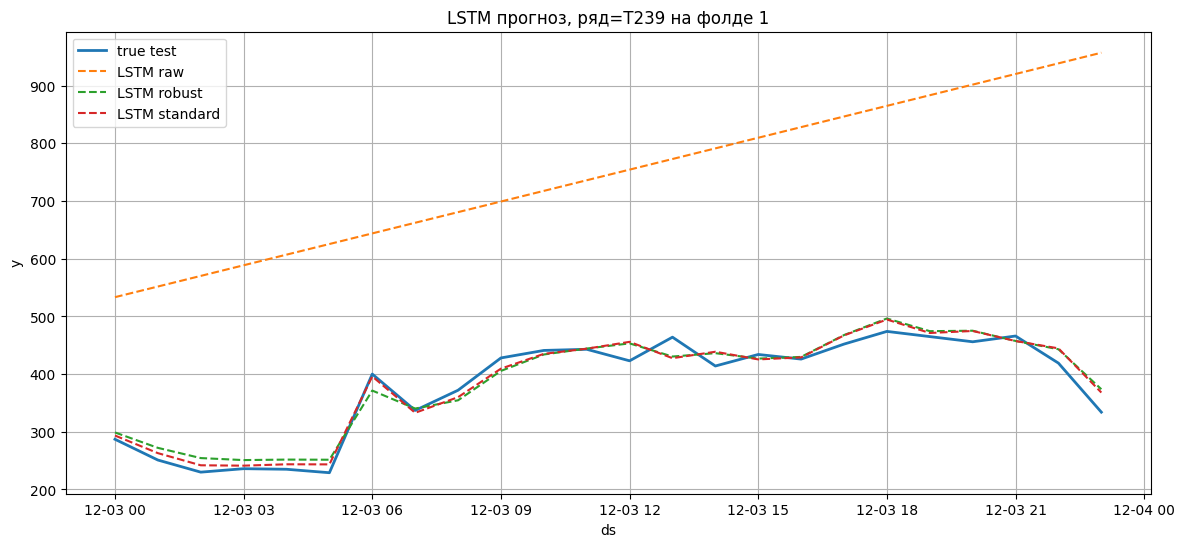

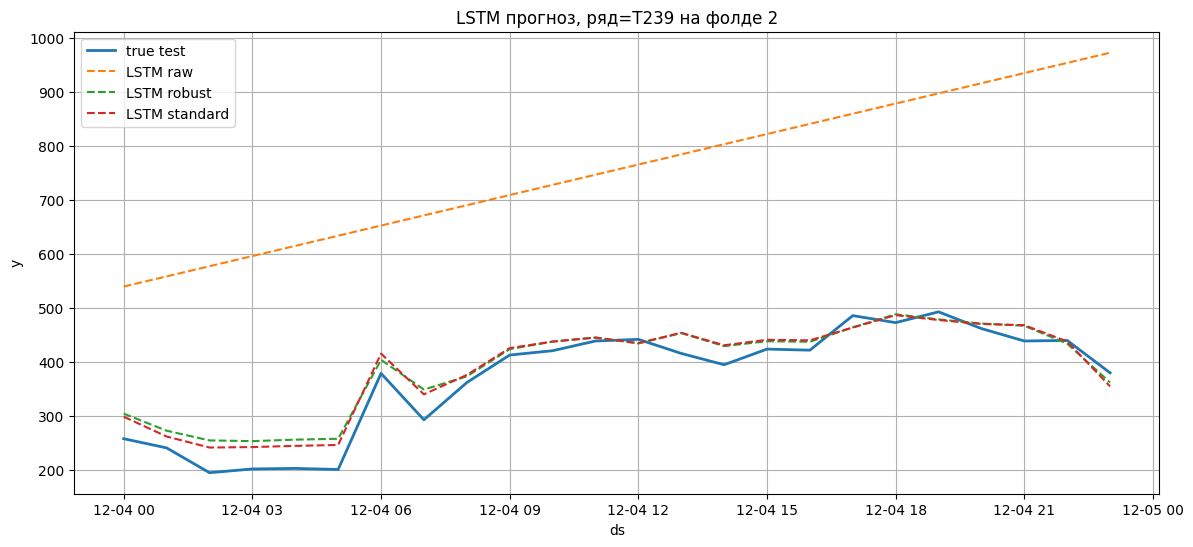

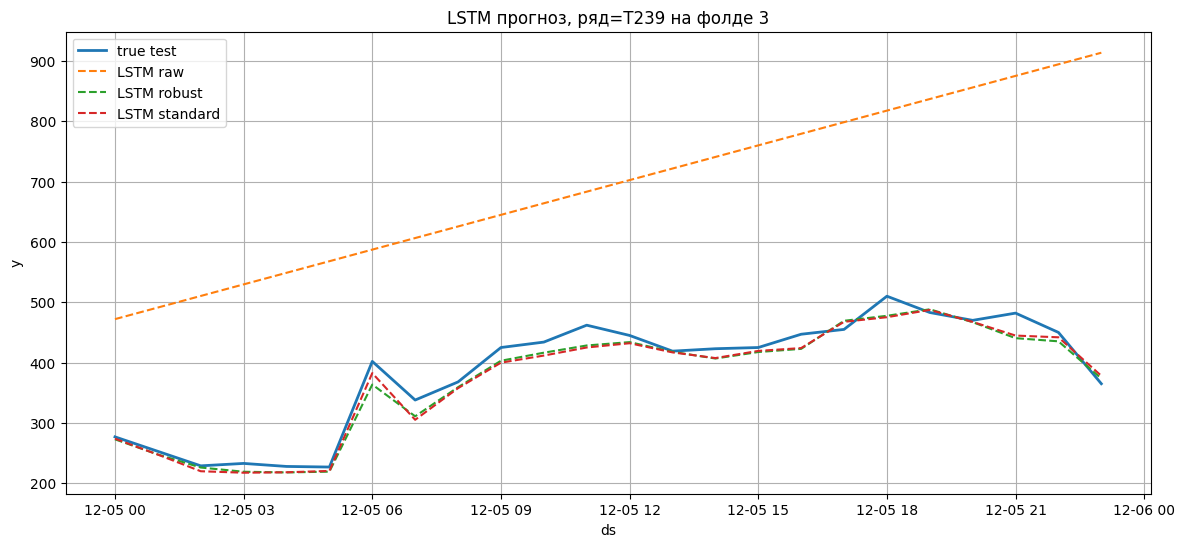

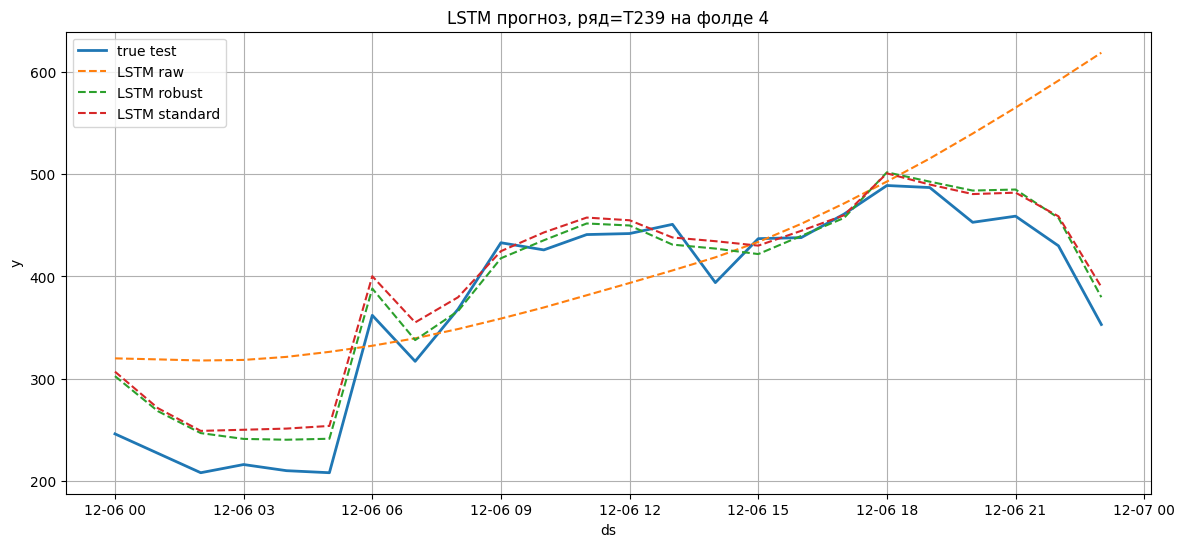

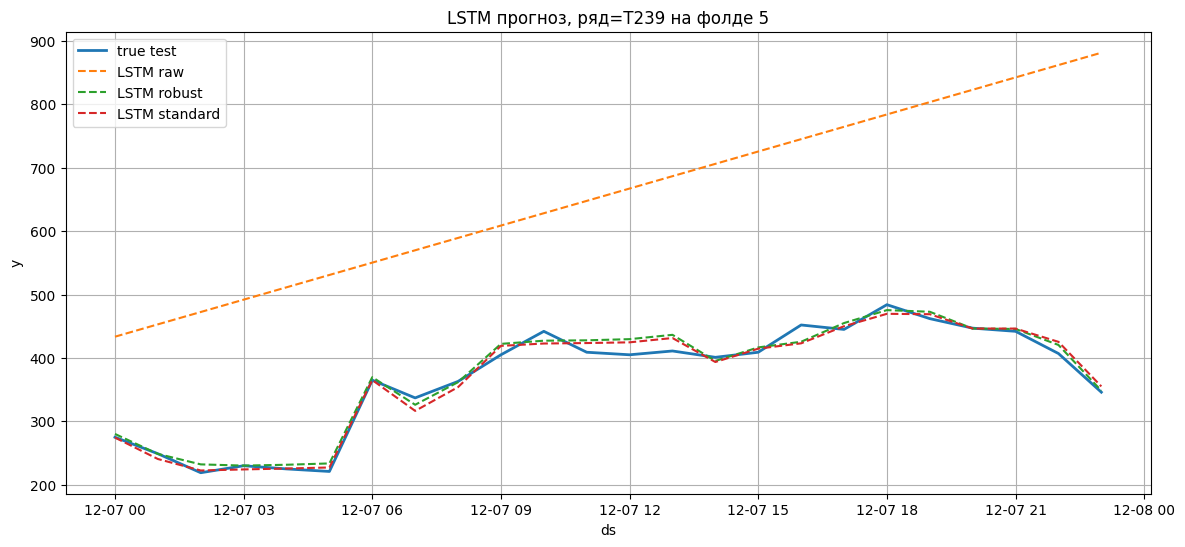

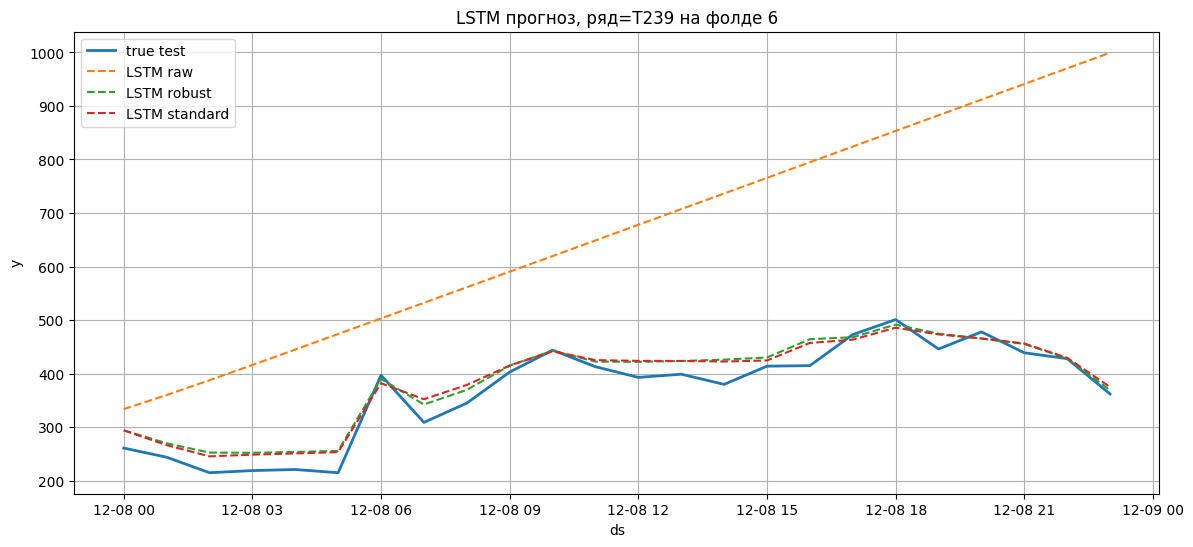

In [50]:
#Пример прогноза для первого фолда, ряд номер 122
ts_example = 'T239'
fold_num = 2

for i in range(1,7,1):
    fold_num = i

    lstm_fc_no_norm = lstm_exog_raw_preds[fold_num].copy()
    lstm_fc_no_norm = lstm_fc_no_norm[lstm_fc_no_norm['unique_id']==ts_example].sort_values('ds')

    lstm_fc_robust = lstm_exog_robust_preds[fold_num].copy()
    lstm_fc_robust = lstm_fc_robust[lstm_fc_robust['unique_id']==ts_example].sort_values('ds')

    lstm_fc_standard = lstm_exog_std_preds[fold_num].copy()
    lstm_fc_standard = lstm_fc_standard[lstm_fc_standard['unique_id']==ts_example].sort_values('ds')

    y_true = lstm_exog_raw_truth[fold_num].copy()
    y_true = y_true[y_true['unique_id'] == ts_example].sort_values('ds')

    plt.figure(figsize=(14, 6))

    plt.plot(y_true['ds'], y_true['y_true'], label='true test', linewidth=2)

    plt.plot(lstm_fc_no_norm['ds'], lstm_fc_no_norm['y_pred'], '--', label='LSTM raw')
    plt.plot(lstm_fc_robust['ds'], lstm_fc_robust['y_pred'], '--', label='LSTM robust')
    plt.plot(lstm_fc_standard['ds'], lstm_fc_standard['y_pred'], '--', label='LSTM standard')

    plt.title(f'LSTM прогноз, ряд={ts_example} на фолде {fold_num}')
    plt.xlabel('ds')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()


Наверное, тут все очевидно - LSTM без обработки оч плохо справляется, обе нормализации дают существенный прирост в качестве

**Анализ результатов Катбуста**

In [60]:
catboost_results_table = (
    results_df[results_df["model"].str.startswith("CatBoost")]
    .groupby("model")[["macro_RMSE", "macro_MAE", "macro_sMAPE"]]
    .agg(["mean", "std"])
    .round(3)
)

catboost_results_table

macro_RMSE         macro_MAE         macro_sMAPE  \
                               mean     std      mean     std        mean   
model                                                                       
CatBoost_NO_SCALER          135.860  23.516   108.536  16.806      11.711   
CatBoost_POWER_TRANSFORM    118.006  22.857    93.266  14.460       9.193   
CatBoost_ROBUST_SCALER      119.221  23.731    93.866  15.335       9.493   
CatBoost_STANDARD_SCALER    116.163  21.741    91.207  12.925       9.226   

                                 
                            std  
model                            
CatBoost_NO_SCALER        2.155  
CatBoost_POWER_TRANSFORM  1.361  
CatBoost_ROBUST_SCALER    1.515  
CatBoost_STANDARD_SCALER  1.427

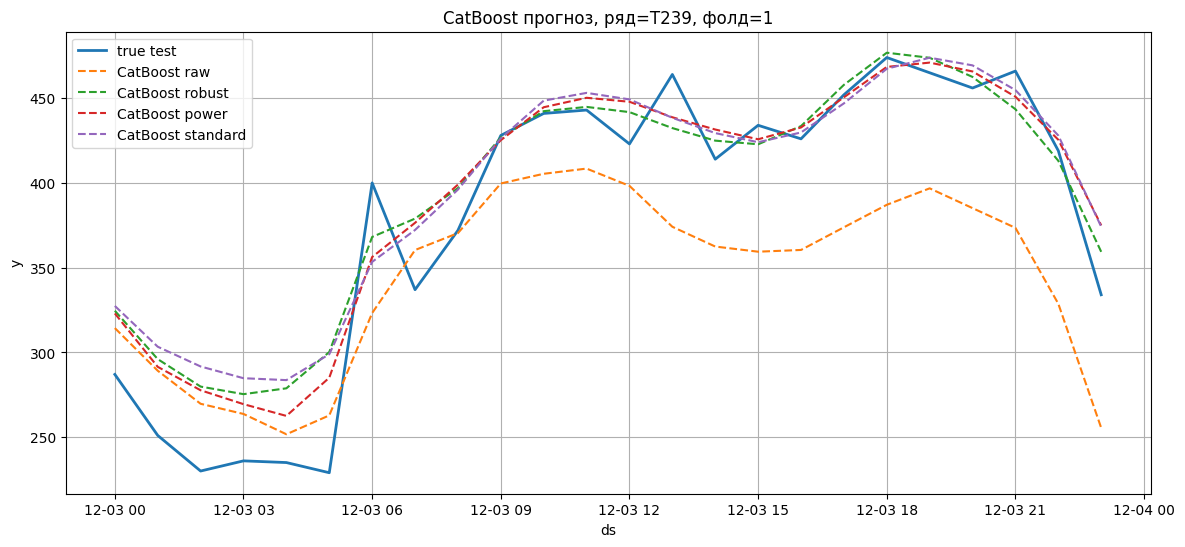

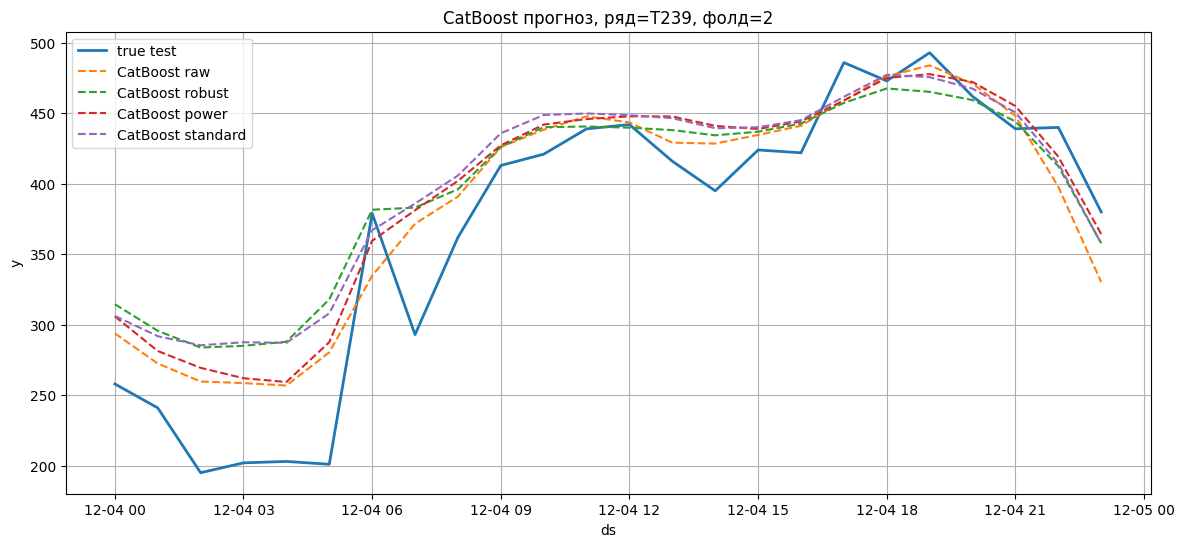

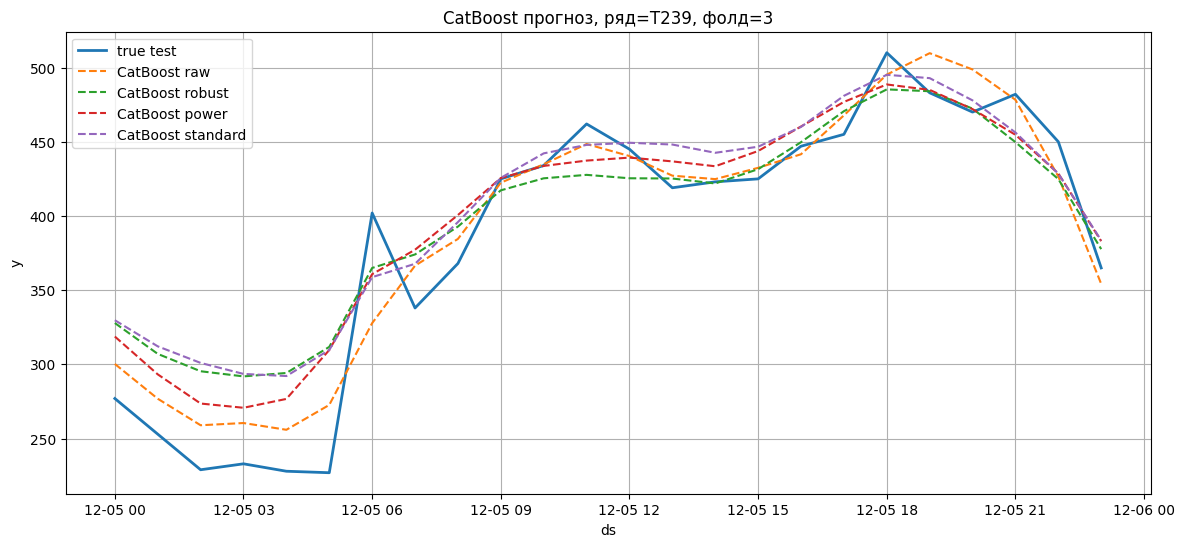

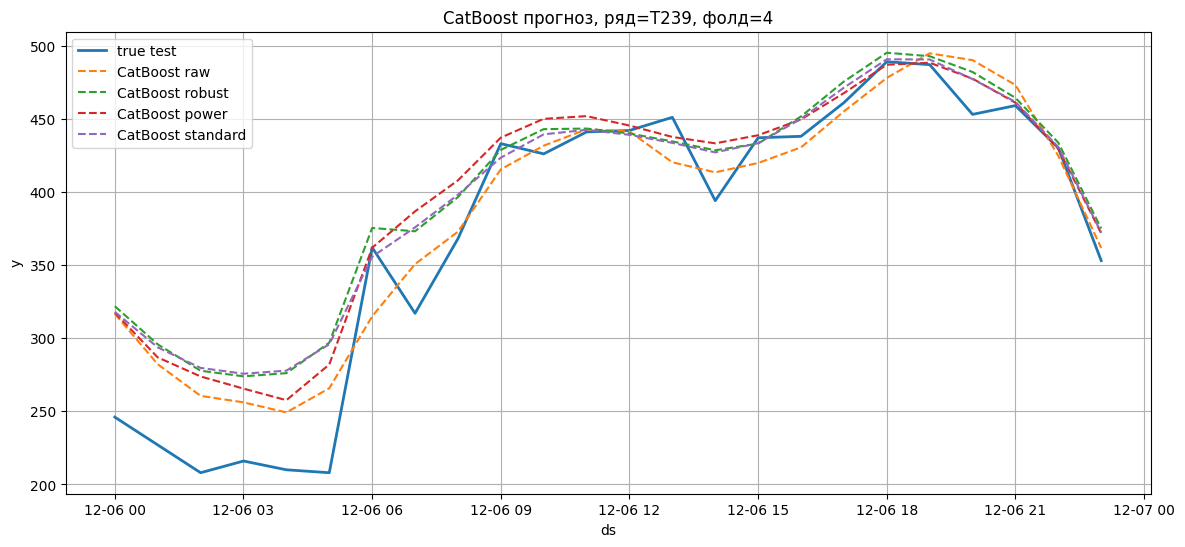

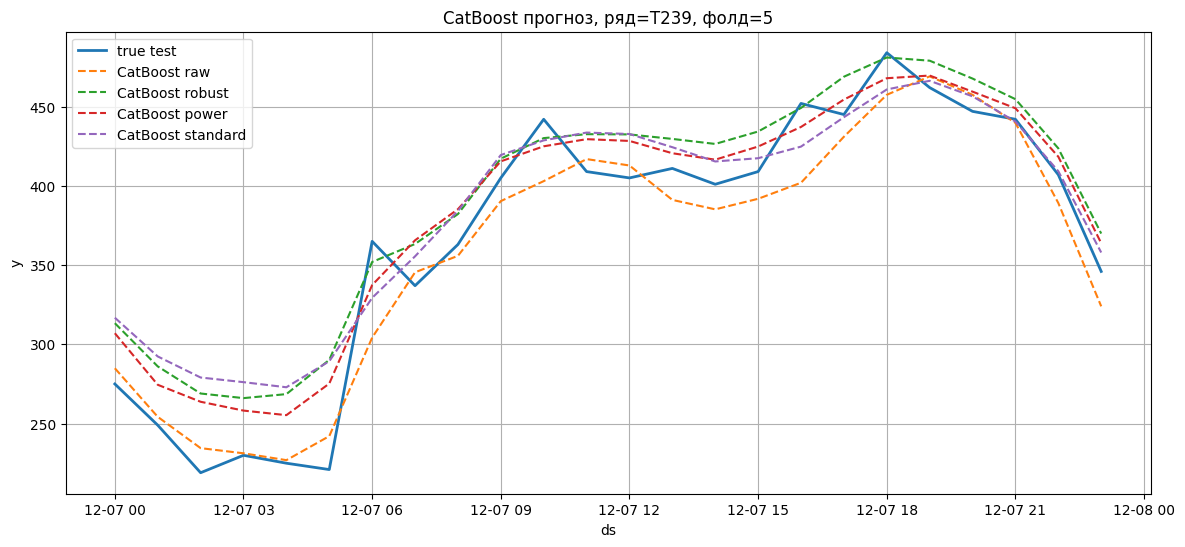

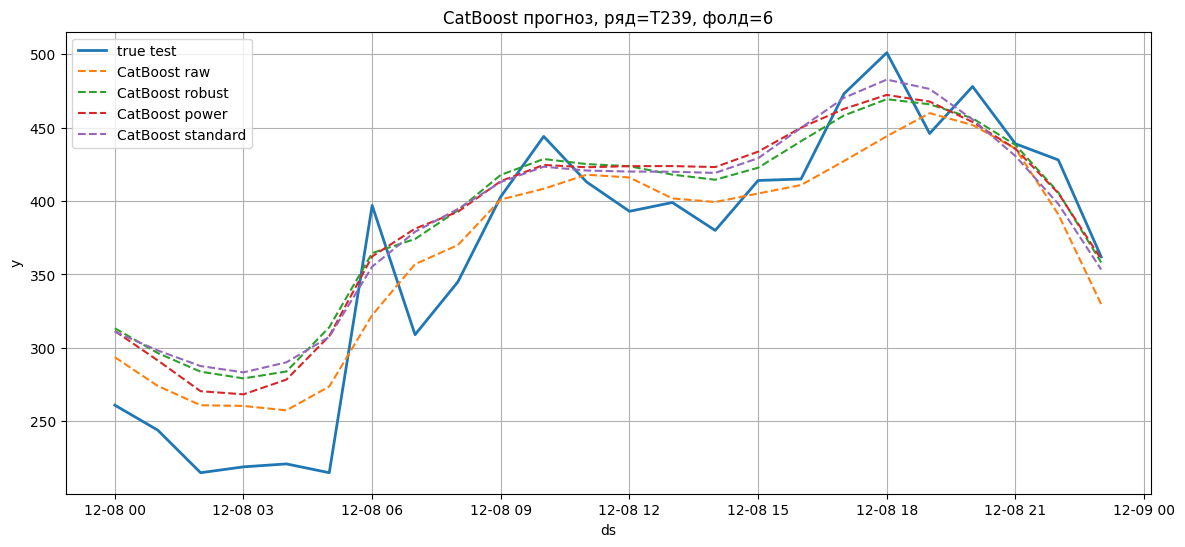

In [52]:
for i in range(1,7,1):

    fold_num = i

    catboost_fc_no_norm = catboost_raw_preds[fold_num].copy()
    catboost_fc_no_norm = catboost_fc_no_norm[
        catboost_fc_no_norm['unique_id'] == ts_example
    ].sort_values('ds')

    catboost_fc_robust = catboost_robust_preds[fold_num].copy()
    catboost_fc_robust = catboost_fc_robust[
        catboost_fc_robust['unique_id'] == ts_example
    ].sort_values('ds')

    catboost_fc_power = catboost_power_preds[fold_num].copy()
    catboost_fc_power = catboost_fc_power[
        catboost_fc_power['unique_id'] == ts_example
    ].sort_values('ds')

    catboost_fc_standard = catboost_std_preds[fold_num].copy()
    catboost_fc_standard = catboost_fc_standard[
        catboost_fc_standard['unique_id'] == ts_example
    ].sort_values('ds')

    y_true = catboost_raw_truth[fold_num].copy()
    y_true = y_true[
        y_true['unique_id'] == ts_example
    ].sort_values('ds')

    plt.figure(figsize=(14, 6))

    plt.plot(y_true['ds'], y_true['y_true'], label='true test', linewidth=2)

    plt.plot(catboost_fc_no_norm['ds'], catboost_fc_no_norm['y_pred'], '--', label='CatBoost raw')
    plt.plot(catboost_fc_robust['ds'], catboost_fc_robust['y_pred'], '--', label='CatBoost robust')
    plt.plot(catboost_fc_power['ds'], catboost_fc_power['y_pred'], '--', label='CatBoost power')
    plt.plot(catboost_fc_standard['ds'], catboost_fc_standard['y_pred'], '--', label='CatBoost standard')

    plt.title(f'CatBoost прогноз, ряд={ts_example}, фолд={fold_num}')
    plt.xlabel('ds')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()


Как мы видим, влияние предобработки значений в случае Катбуста менее выраженно - разница в результатах не так значительна, в зависимости от фолда и времени различные стратегии преодбработки оказываются лучше/хуже, в отдельных случаях прогноз на "сырых" данных оказывается более точным

Усредненно power transform показывает наилучший результат.

Для полноты эксперимента сделаем также transform на AutoETS

In [53]:

def fit_power_transformers(train_long: pd.DataFrame, target_col: str = "y"):
    transformers = {}

    for uid, g in train_long.groupby("unique_id", sort=False):
        transformer = PowerTransformer(method="yeo-johnson", standardize=True)
        transformer.fit(g[[target_col]].values)
        transformers[uid] = transformer

    return transformers


def apply_power_transform_to_long(
    df_long: pd.DataFrame,
    transformers: dict,
    input_col: str = "y",
    output_col: str = "y_scaled",
):
    parts = []

    for uid, g in df_long.groupby("unique_id", sort=False):
        g = g.copy()
        g[output_col] = transformers[uid].transform(g[[input_col]].values).ravel()
        parts.append(g)

    out = (
        pd.concat(parts, axis=0)
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )
    return out


def inverse_transform_preds_long(
    pred_long: pd.DataFrame,
    transformers: dict,
    pred_col: str = "y_pred",
):
    parts = []

    for uid, g in pred_long.groupby("unique_id", sort=False):
        g = g.copy()
        g[pred_col] = transformers[uid].inverse_transform(g[[pred_col]].values).ravel()
        parts.append(g)

    out = (
        pd.concat(parts, axis=0)
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )
    return out

In [54]:
autoets_power_preds = {}
autoets_power_rmse = {}
autoets_power_mae = {}
autoets_power_msmape = {}
true_values_autoets_power = {}

dataset = (
    data.reset_index()
    .sort_values(["series_name", "timestamp"])
    .reset_index(drop=True)
)

# обучение на каждом фолде
for fold in folds:
    train_long = dataset.loc[
        dataset["timestamp"] <= fold["train_end_time"],
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y"
    })

    val_long = dataset.loc[
        (dataset["timestamp"] >= fold["val_start_time"]) &
        (dataset["timestamp"] <= fold["val_end_time"]),
        ["series_name", "timestamp", "series_value"]
    ].copy().rename(columns={
        "series_name": "unique_id",
        "timestamp": "ds",
        "series_value": "y_true"
    })

    power_transformers = fit_power_transformers(train_long, target_col="y")

    train_long_scaled = apply_power_transform_to_long(
        train_long,
        power_transformers,
        input_col="y",
        output_col="y_scaled",
    )

    train_long_scaled = train_long_scaled[
        ["unique_id", "ds", "y_scaled"]
    ].rename(columns={"y_scaled": "y"})

    sf = StatsForecast(
        models=[AutoETS(season_length=24)],
        freq="h",
        n_jobs=-1,
    )

    model_preds = sf.forecast(df=train_long_scaled, h=HORIZON)
    model_preds = model_preds.rename(columns={"AutoETS": "y_pred"})


    model_preds = inverse_transform_preds_long(
        model_preds,
        power_transformers,
        pred_col="y_pred"
    )

    fold_result = val_long.merge(
        model_preds,
        on=["unique_id", "ds"],
        how="left"
    )

    autoets_power_preds[fold["fold"]] = fold_result[["unique_id", "ds", "y_pred"]]
    true_values_autoets_power[fold["fold"]] = fold_result[["unique_id", "ds", "y_true"]]

    # метрики и сохранение результата
    rmse_fold = RMSE(fold_result["y_true"].values, fold_result["y_pred"].values)
    mae_fold = MAE(fold_result["y_true"].values, fold_result["y_pred"].values)
    msmape_fold = mSMAPE(fold_result["y_true"].values, fold_result["y_pred"].values)

    autoets_power_rmse[fold["fold"]] = rmse_fold
    autoets_power_mae[fold["fold"]] = mae_fold
    autoets_power_msmape[fold["fold"]] = msmape_fold

    print(
        f"Fold: {fold['fold']} | RMSE= {round(rmse_fold, 2)} | "
        f"MAE= {round(mae_fold, 2)} | SMAPE= {round(msmape_fold, 2)}"
    )

Fold: 1 | RMSE= 164.09 | MAE= 81.37 | SMAPE= 9.5
Fold: 2 | RMSE= 200.24 | MAE= 88.21 | SMAPE= 9.32
Fold: 3 | RMSE= 212.57 | MAE= 97.86 | SMAPE= 8.76
Fold: 4 | RMSE= 175.78 | MAE= 92.98 | SMAPE= 10.41
Fold: 5 | RMSE= 171.65 | MAE= 88.54 | SMAPE= 10.24
Fold: 6 | RMSE= 123.62 | MAE= 69.79 | SMAPE= 8.0
Fold: 7 | RMSE= 341.55 | MAE= 115.5 | SMAPE= 11.28


In [57]:
autoets_power_results = build_model_results_df(
    "AutoETS_POWER_TRANSFORM",
    autoets_power_preds,
    true_values_autoets_power
)

results_df = pd.concat(
    [results_df, autoets_power_results],
    ignore_index=True
).sort_values(["model", "fold"]).reset_index(drop=True)


**Общие результаты других моделей:**

In [58]:
results_df

,model,fold,pooled_RMSE,pooled_MAE,pooled_sMAPE,macro_RMSE,macro_MAE,macro_sMAPE,n_series,n_rows
0,AutoETS,1,163.417133,81.284168,9.393986,97.915826,81.284168,9.393986,20,480
1,AutoETS,2,198.275040,87.149580,9.515405,106.255246,87.149580,9.515405,20,480
2,AutoETS,3,219.589570,102.102508,10.062269,118.670529,102.102508,10.062269,20,480
3,AutoETS,4,174.673321,90.944666,9.899887,115.231156,90.944666,9.899887,20,480
4,AutoETS,5,170.387244,88.957989,10.238526,105.362197,88.957989,10.238526,20,480
...,...,...,...,...,...,...,...,...,...,...
72,SeasonalNaive_24,3,236.551294,94.356250,6.717901,118.898628,94.356250,6.717901,20,480
73,SeasonalNaive_24,4,206.811710,97.070833,9.268492,126.232244,97.070833,9.268492,20,480
74,SeasonalNaive_24,5,156.001723,78.279167,10.150234,101.751850,78.279167,10.150234,20,480
75,SeasonalNaive_24,6,110.393840,60.870833,7.938007,83.885838,60.870833,7.938007,20,480


Seasonal Naive (s=24)

In [61]:
seas_naive_results_table = (
    results_df[results_df["model"].str.startswith("Seasonal")]
    .groupby("model")[["macro_RMSE", "macro_MAE", "macro_sMAPE"]]
    .agg(["mean", "std"])
    .round(3)
)

seas_naive_results_table

macro_RMSE         macro_MAE         macro_sMAPE       
                       mean     std      mean     std        mean    std
model                                                                   
SeasonalNaive_24    113.217  26.306    84.656  17.004       8.568  1.722

AutoETS с и без трансформации

In [62]:
autoets_results_table = (
    results_df[results_df["model"].str.startswith("AutoETS")]
    .groupby("model")[["macro_RMSE", "macro_MAE", "macro_sMAPE"]]
    .agg(["mean", "std"])
    .round(3)
)

autoets_results_table

macro_RMSE         macro_MAE         macro_sMAPE  \
                              mean     std      mean     std        mean   
model                                                                      
AutoETS                    112.961  23.322    91.303  15.159       9.947   
AutoETS_POWER_TRANSFORM    112.635  22.559    90.607  14.180       9.646   

                                
                           std  
model                           
AutoETS                  1.139  
AutoETS_POWER_TRANSFORM  1.098

Итоговая таблица макро-усредненных результатов:

In [63]:
all_models_results_table = (
    results_df
    .groupby("model")[["macro_RMSE", "macro_MAE", "macro_sMAPE"]]
    .agg(["mean", "std"])
    .round(3)
    .sort_values(("macro_RMSE", "mean"))
)

all_models_results_table

macro_RMSE          macro_MAE          macro_sMAPE  \
                               mean      std      mean      std        mean   
model                                                                         
AutoETS_POWER_TRANSFORM     112.635   22.559    90.607   14.180       9.646   
AutoETS                     112.961   23.322    91.303   15.159       9.947   
SeasonalNaive_24            113.217   26.306    84.656   17.004       8.568   
CatBoost_STANDARD_SCALER    116.163   21.741    91.207   12.925       9.226   
LSTM_exog_robust            116.659   18.009    91.878   11.435       8.917   
CatBoost_POWER_TRANSFORM    118.006   22.857    93.266   14.460       9.193   
CatBoost_ROBUST_SCALER      119.221   23.731    93.866   15.335       9.493   
LSTM_exog_standard          119.532   18.701    94.386   13.301       8.883   
CatBoost_NO_SCALER          135.860   23.516   108.536   16.806      11.711   
Naive                       451.079   26.381   396.521   23.417      33.063   
LSTM_exog_raw              1171.560  310.792  1098.532  328.396      66.093   

                                  
                             std  
model                             
AutoETS_POWER_TRANSFORM    1.098  
AutoETS                    1.139  
SeasonalNaive_24           1.722  
CatBoost_STANDARD_SCALER   1.427  
LSTM_exog_robust           1.734  
CatBoost_POWER_TRANSFORM   1.361  
CatBoost_ROBUST_SCALER     1.515  
LSTM_exog_standard         1.772  
CatBoost_NO_SCALER         2.155  
Naive                      1.433  
LSTM_exog_raw             14.807